# Mind the Gap!

In the lecture we discussed a lot about feature encoding, which is part of feature engineering. But what if we have gaps in the data? How do we deal with that? In this exercise, we want you to explore different ways of dealing with gaps in the data.

## 1) Importing Libraries 

First, we need to import our standard libraries for plotting and numerical operations:

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In order to visualize high dimensional data, we will use a so-called UMAP plot (see next module) that projects the data to two or three dimensions. Therefore, we will need the following library: 

In [1]:
import umap.umap_ as umap # pip install umap-learn

Next, we need to import a few more libraries in order to work with the data set. One library is needed for scaling (see lecture) and the other one will be useful at the end of this exercise.

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

<br>

## 2) Importing the Data Set

The data set we will be working with is a medical study about diabetes, where the features are medical records containing blood values, BMI etc, and the target value $Y = Outcome$ indicades if the patient is healthy ($Y = 0$) or if the patient has diabetes ($Y = 1$). The goal of that study was to predict the risk of getting diabetes based on the given features. 

In [3]:
url     = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

In [6]:
columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
Data    = pd.read_csv(url, names=columns)

In [7]:
Data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<br>

## 3) Exercise

3.1) Explore the data set:<br>
- create a pair plot like to one in the lecture (last slide): Do some of the features correlate? Are there gaps in the data or is there anything unusual?<br>
- run UMAP on the data features via<br>
   ```python
      newXY = umap.UMAP().fit_transform(X)
    ```
  and highlight the data points according to their $Y$ value (healthy/diabetes). Do the patients cluster according to their health status? 

In [9]:
"""
your code here:
"""
X = Data.drop("Outcome", axis = 1)
Y = Data[["Outcome"]]

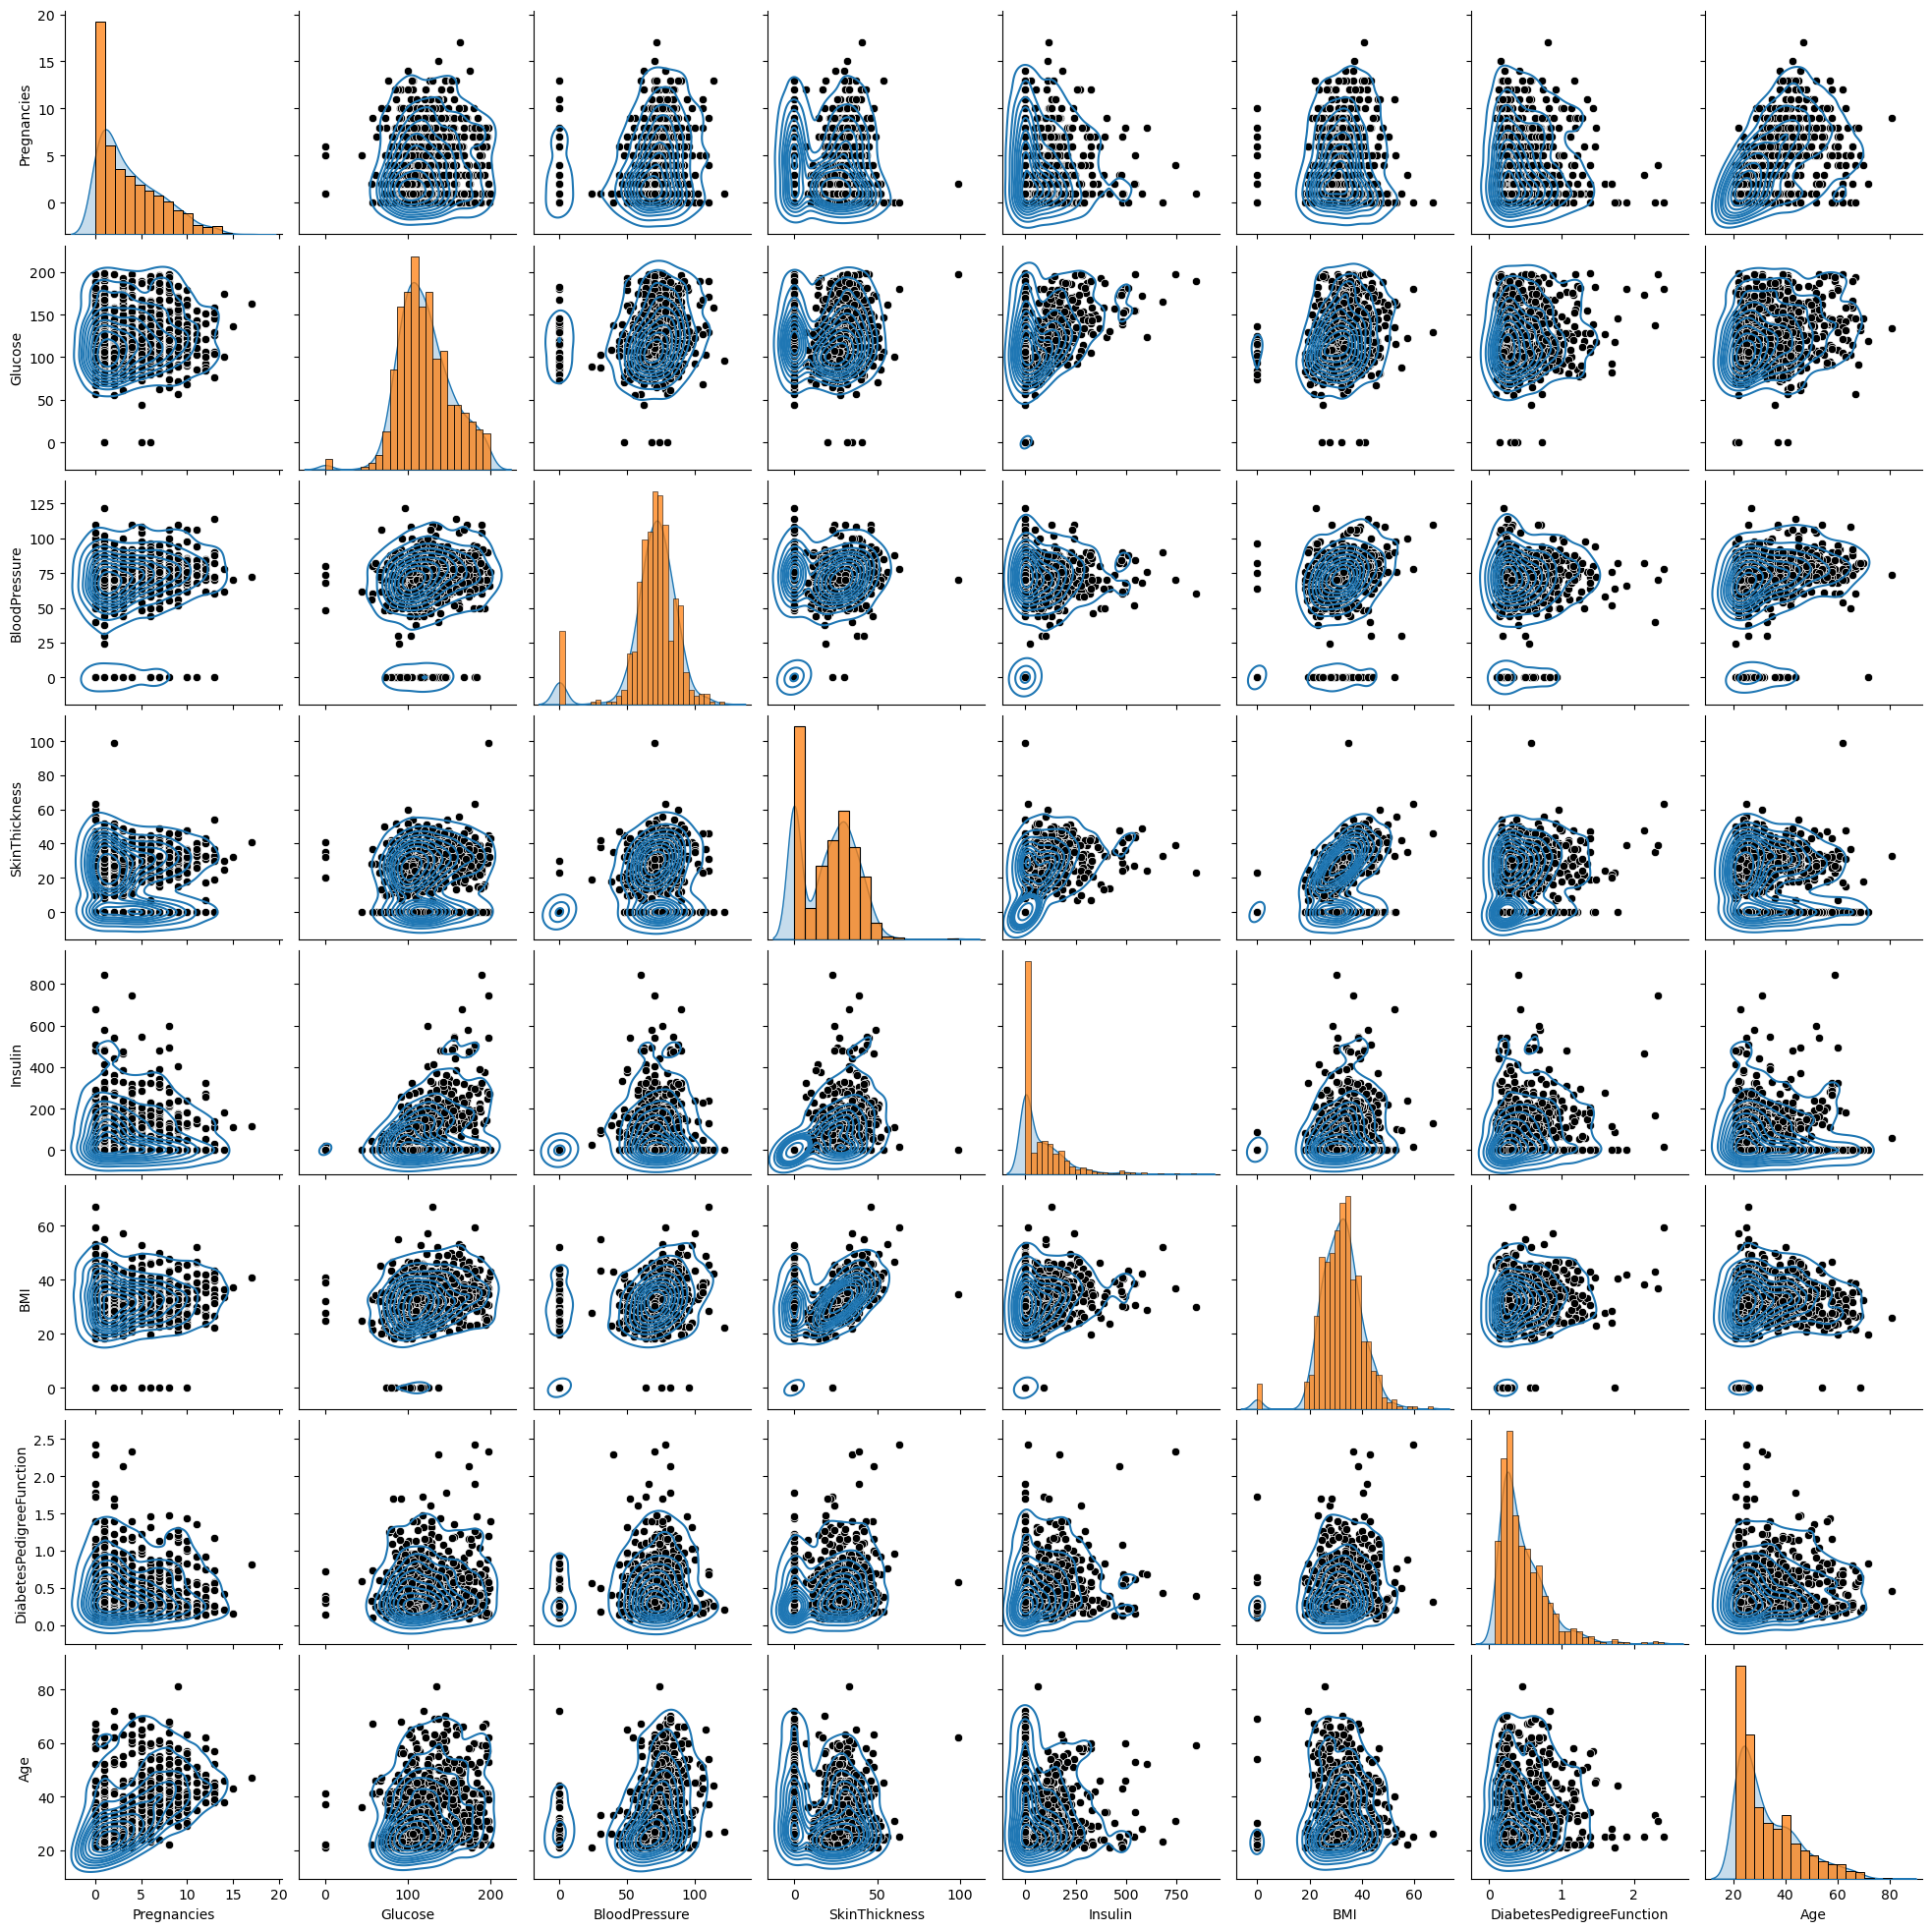

In [10]:
#3.1) create a pair plot:
Pair = sns.pairplot(X, kind = 'kde')
Pair.map_lower(sns.scatterplot, c = 'k')
Pair.map_upper(sns.scatterplot, c = 'k')
Pair.map_diag(sns.histplot, stat = 'density')
plt.show()

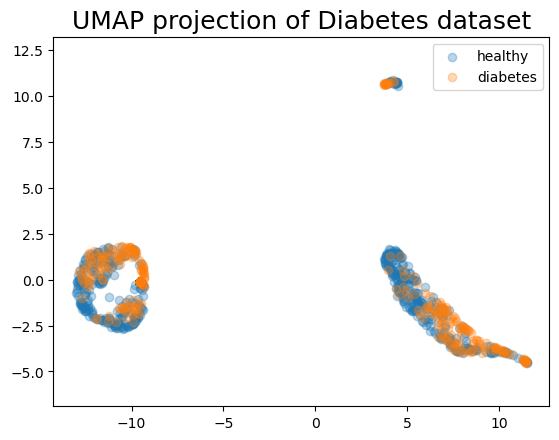

In [11]:
idx0 = np.argwhere(Y == 0) 
idx1 = np.argwhere(Y == 1) 

#3.1) create a UMAP plot:
newXY = umap.UMAP().fit_transform(X)
plt.scatter(newXY[idx0, 0], newXY[idx0, 1], alpha = 0.3, label = 'healthy')
plt.scatter(newXY[idx1, 0], newXY[idx1, 1], alpha = 0.3, label = 'diabetes')
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of Diabetes dataset', fontsize = 18)
plt.legend()
plt.show()

- data seems to cluster, but not according to health status<br>
- lots of zeros: indicades missing values<br>
- zeros are not a good placeholder: could be an actual value!<br>

<br>

3.2) Removing incomplete data

- Replace the zeros, which indicate missing values, in the following columns with $NaNs$

In [15]:
ColsZeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

but keep the original data. Note that **dataframes are mutable!**

- create a pair plot like to one before, but without including the patients who have uncomplete records. 
- **scale the features** of the filtered data (no NaNs) and generate a UMAP plot as before. Do the patients cluster according to their health status now?
- Discuss disadvantages of this method!

In [ ]:
"""
your code here:
"""

*your answers here*